# Network-ids-ton-iot

## Problem Definition
This project addresses Network Intusion Detection using the TON-IoT network dataset.

The problem is formulated as a two-staged task.

### Stage 1 - Binary Intrusion Detection:
The model determines whether a network connection represents normal traffic or malicious.

### Stage 2 - Ataack Classification:
For connections identified as malicious, the model predicts the specific attack category.

This separation reflects the operational structure of an intrusion detection system:

Detecting an incident is the first decision, followed by identifying the type of attack.

## Why Two Separate Models?

The dataset contains two potential target variables: `label` (binary:
normal/attack) and `type` (10 classes: normal + 9 attack categories).

Upon examining the target distribution, the following table emerges:

- `label`: 76.3% attack (161,043), 23.7% normal (50,000)
- `type`: Every attack category except Normal (50,000) contains approximately 20,000 examples;
  **there are only 1,043 examples in the MITM category (0.49%)** — a significant
  class imbalance exists

A two-stage approach was preferred over a single multi-class model:
- **Stage 1 (Binary)**: The `type` column is removed because it leaks information;
  the model learns to distinguish between normal and attack based solely on `label`
- **Stage 2 (Multi-Class)**: The `label` column is removed, and attack
  type classification is performed only on rows marked as attacks
  (`type != “normal”`)

This distinction ensures that both problem types (binary and multi-class) are addressed separately in all steps covered by the assignment (training/validation/test split, model comparison,
hyperparameter tuning, explainability).

## Key Questions

1. How imbalanced is the binary intrusion-detection target?

2. Which network-level characteristics distinguish normal from malicious
   traffic?

3. Which attack categories are represented in the malicious traffic,
   and how balanced are they?

4. Are missing-value patterns actually missing data, or do they represent
   protocol-specific fields that are not applicable to a connection?

5. Which features behave as identifiers, categorical codes, sparse
   protocol-specific fields or continuous measurements?

6. Are duplicate observations present, and could random splitting cause
   overly optimistic evaluation?

7. Which network-derived features provide additional information beyond
   the original variables?

8. Which features are selected by the model after preprocessing?

9. Which attack classes are difficult to distinguish?

10. Which network protocols are associated with the model's errors?

## Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns",None)

project_root = Path.cwd().resolve()
if project_root.name == "notebook":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    DATA_FILE, 
    BINARY_TARGET_COLUMN,
    ATTACK_TARGET_COLUMN,
    BINARY_LEAKAGE_COLUMNS,
    ATTACK_LEAKAGE_COLUMNS,
    RANDOM_STATE
)
from src.data_loader import load_data
from src.data_validation import validate_dataset

from src.data_profile import (
    get_missing_summary,
    get_duplicate_summary,
    get_numeric_summary,
    get_categorical_summary,
    get_cardinality_summary,
    get_target_distribution,
    get_target_rate
)

from src.visualization import (
    plot_class_distribution,
    plot_numeric_distribution,
    plot_outliers,
    plot_correlation_heatmap,
    plot_confusion_matrix,
    plot_model_comparison,
    plot_shap_summary
)

from src.data_split import split_data, encode_target

from src.preprocessing import (
    replace_missing_markers,
    get_numeric_columns,
    get_categoric_columns,
    strip_strings,
    build_preprocessor,
    remove_exact_duplicates
)

from src.feature_engineering import create_features

from src.modeling import get_models, compare_models

from src.modeling import tune_best_model,get_param_grid

from src.evaluation import (
    evaluate_on_test, 
    get_feature_importance,
    analyze_errors
)

c:\Users\beste\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading & Inspection

In [2]:
df = load_data(DATA_FILE)
df.head()

2026-08-13 23:42:25,535 - INFO - data_loader - Starting read from CSV: C:\Users\beste\Desktop\huawei-trai-data-science-ml-bootcamp\machine-learning-assignment-2\dataset\Train_Test_Network_dataset\train_test_network.csv
2026-08-13 23:42:26,381 - INFO - data_loader - Data loaded successfully. rows=211043, columns=44


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor


In [3]:
df = strip_strings(df)
df = replace_missing_markers(df)
df.head(5)

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,NaN,290.371539,101568,2592,OTH,0,108,108064,31,3832,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000102,0,0,REJ,0,1,52,1,40,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000148,0,0,REJ,0,1,52,1,40,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000113,0,0,REJ,0,1,48,1,40,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000130,0,0,REJ,0,1,52,1,40,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor


In [4]:
validate_dataset(df, BINARY_TARGET_COLUMN)

2026-08-13 23:42:27,645 - INFO - data_validation - Starting dataset validation pipeline...
2026-08-13 23:42:27,648 - INFO - data_validation - Target column 'label' is present in the dataset.
2026-08-13 23:42:28,118 - WARNING - data_validation - Dataset contains 20569 duplicated rows.
2026-08-13 23:42:28,120 - WARNING - data_validation - Dataset validation completed with duplicated rows.
2026-08-13 23:42:28,121 - INFO - data_validation - Dataset validation pipeline completed successfully!


True

In [5]:
df.shape

(211043, 44)

In [6]:
df.columns

Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  str    
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  str    
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  str    
 5   service                 79011 non-null   str    
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  str    
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes            211043 

In [8]:
df.dtypes

src_ip                        str
src_port                    int64
dst_ip                        str
dst_port                    int64
proto                         str
service                       str
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                    str
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                     str
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                        str
dns_RD                        str
dns_RA                        str
dns_rejected                  str
ssl_version                   str
ssl_cipher                    str
ssl_resumed                   str
ssl_established               str
ssl_subject                   str
ssl_issuer                    str
http_trans_dep

In [9]:
df.type.value_counts()

type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64

### Describe numeric features:

In [10]:
get_numeric_summary(df)

,count,mean,std,min,25%,50%,75%,max
src_port,211043.0,38646.519543,1.930727e+04,1.0,34608.0,44754.00000,51133.000000,6.552800e+04
dst_port,211043.0,3495.153770,1.019162e+04,0.0,65.0,80.00000,1253.000000,6.546700e+04
duration,211043.0,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,211043.0,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,211043.0,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09
missed_bytes,211043.0,34432.344295,5.261621e+06,0.0,0.0,0.00000,0.000000,1.854527e+09
src_pkts,211043.0,9.595220,9.177882e+01,0.0,1.0,1.00000,4.000000,2.462300e+04
src_ip_bytes,211043.0,776.082206,2.229703e+04,0.0,48.0,82.00000,415.000000,6.522626e+06
dst_pkts,211043.0,3.846861,3.307058e+02,0.0,0.0,1.00000,2.000000,1.219420e+05
dst_ip_bytes,211043.0,1584.686628,1.901795e+05,0.0,0.0,40.00000,134.000000,8.639552e+07


heavy-tailed / zero-inflated

### Describe categoric features:

In [11]:
get_categorical_summary(df)

,count,unique,top,freq
src_ip,211043,51,192.168.1.30,61633
dst_ip,211043,753,192.168.1.190,47795
proto,211043,3,tcp,168747
service,79011,8,dns,39446
conn_state,211043,13,S0,51937
dns_query,34845,725,a2z3kk2ebqzso7.iot.ap-southeast-2.amazonaws.com,11318
dns_AA,35013,2,F,33607
dns_RD,35013,2,T,27002
dns_RA,35013,2,F,30623
dns_rejected,35013,2,F,28873


Sparse protocol-specific fields modele gerçekten katkı sağlıyor mu?

## Data Quality

In [12]:
missing_summary = get_missing_summary(df)
if missing_summary["missing row count"]>0:
    print(
        f"Missing Values: "
        f"{missing_summary['missing rows'].head()}"
    )

2026-08-13 23:42:29,072 - INFO - data_profile - Total rows with missing values: 211043


Missing Values:           src_ip  src_port         dst_ip  dst_port proto service    duration  \
0   192.168.1.37      4444  192.168.1.193     49178   tcp     NaN  290.371539   
1  192.168.1.193     49180   192.168.1.37      8080   tcp     NaN    0.000102   
2  192.168.1.193     49180   192.168.1.37      8080   tcp     NaN    0.000148   
3  192.168.1.193     49180   192.168.1.37      8080   tcp     NaN    0.000113   
4  192.168.1.193     49180   192.168.1.37      8080   tcp     NaN    0.000130   

   src_bytes  dst_bytes conn_state  missed_bytes  src_pkts  src_ip_bytes  \
0     101568       2592        OTH             0       108        108064   
1          0          0        REJ             0         1            52   
2          0          0        REJ             0         1            52   
3          0          0        REJ             0         1            48   
4          0          0        REJ             0         1            52   

   dst_pkts  dst_ip_bytes dns_query  dns

### Missing-Value Interpretation

Missing values are not automatically considered invalid records.

The network dataset contains prtocol-specific fields. For example, SSL related fields are not applicable to connections without SSL, wh,le HTTP/DNS fields may be absent for connections that do not use those protocols.

Therefore, missingness is interpreted as structural missigness rather than a reason to remove the corresponding observations.

The preprocessing pipeline handles remaining missing values according to feature type.

In [13]:
duplicated_summary = get_duplicate_summary(df)
duplicated_rows = duplicated_summary["duplicated rows"]
if duplicated_summary["duplicated row count"]>0:
    print(f"Duplicated Rows: {duplicated_rows}")

2026-08-13 23:42:29,606 - INFO - data_profile - Duplicated row count: 27739


Duplicated Rows:                src_ip  src_port          dst_ip  dst_port proto service  \
19      192.168.1.193     49180    192.168.1.37      8080   tcp     NaN   
21      192.168.1.193     49180    192.168.1.37      8080   tcp     NaN   
136     192.168.1.193     49194    192.168.1.33      8080   tcp     NaN   
151     192.168.1.193     49194    192.168.1.33      8080   tcp     NaN   
319     192.168.1.193     49234    192.168.1.37      8080   tcp     NaN   
...               ...       ...             ...       ...   ...     ...   
211032   192.168.1.32     47514  18.194.169.124        80   tcp     NaN   
211033   192.168.1.32     47518  18.194.169.124        80   tcp     NaN   
211034   192.168.1.32     47634  18.194.169.124        80   tcp     NaN   
211035   192.168.1.32     48134  18.194.169.124        80   tcp     NaN   
211036   192.168.1.32     48156  18.194.169.124        80   tcp     NaN   

        duration  src_bytes  dst_bytes conn_state  missed_bytes  src_pkts  \
19   

### Duplicate Record Analysis

Since the duplicate record detection process uses two different definitions, two separate counts are reported. `duplicated()` counts duplicate records following the first record,
while `duplicated(keep=False)` flags every record belonging to a group of duplicate records. Therefore, these counts should not be interpreted as conflicting results.

* Are there duplicate records, and could they affect model evaluation?

Duplicate records are concentrated in several attack categories. Because repeated network events can represent repeated attack activity,they were retained rather than automatically removed.

However, random train/test splitting can place identical records in both training and test sets. Therefore, the reported test performance may be optimistic and this is considered a limitation of the evaluation.

In [14]:
duplicated_rows["label"].value_counts(normalize=True)

label
1    0.707163
0    0.292837
Name: proportion, dtype: float64

In [15]:
duplicated_rows["type"].value_counts()

type
normal        8123
xss           8039
ransomware    6774
backdoor      2512
dos           2016
password       209
injection       48
ddos            14
mitm             4
Name: count, dtype: int64

In [16]:
get_cardinality_summary(df)

dst_ip                  753
dns_query               725
http_uri                 85
src_ip                   51
http_user_agent          34
conn_state               13
weird_name               10
http_trans_depth         10
type                     10
http_resp_mime_types      9
service                   8
ssl_cipher                5
ssl_subject               5
ssl_issuer                4
http_method               3
ssl_version               3
proto                     3
dns_RD                    2
dns_AA                    2
dns_rejected              2
dns_RA                    2
ssl_resumed               2
ssl_established           2
weird_addl                2
http_orig_mime_types      2
http_version              1
weird_notice              1
dtype: int64

* Which features have very high cardinality or very low information?

dst_ip       753

dns_query    725

src_ip        51


http_version → 1

weird_notice  → 1

### Data Type Validation

In [17]:
df.dtypes.value_counts()

str        27
int64      16
float64     1
Name: count, dtype: int64

## Data Cleaning

Data CleaningThere are 3 types of columns that will confuse the model and must be deleted from the dataset:
- Single-Value Columns: Columns where all rows contain the exact same value cannot teach anything to the model.
- High-Cardinality Identifiers: Unique values that change completely in every row cause the machine learning model to memorize (overfitting).
- Data Leakage Columns: Columns that leak information about the target variable in advance—which would be unavailable in real-world scenarios—lead to misleadingly high performance.

For example, the type column is excluded because it directly represents the traffic class used to derive the binary target label. Using it as a feature would introduce target leakage.

### Duplicate Record Handling

The dataset contains exact duplicate rows. If identical observations appear in both
training and test partitions, a random split can produce overly optimistic scores
because the model may be evaluated on records it has effectively already seen.

Therefore, exact duplicates were removed before train-validation-test splitting.
This does not guarantee real-world generalization, but it prevents identical
feature records from appearing in both partitions.

The number of removed rows is recorded in the application log.

In [18]:
df = remove_exact_duplicates(df)
print(f"Dataset shape after exact duplicate removal: {df.shape}")
duplicated_summary = get_duplicate_summary(df)

2026-08-13 23:42:30,416 - INFO - preprocessing - Removed exact duplicates: 20569. Rows remaining: 190474.


Dataset shape after exact duplicate removal: (190474, 44)


2026-08-13 23:42:30,840 - INFO - data_profile - Duplicated row count: 0


## Exploratory Data Analysis

### Binary Target Analysis

In [19]:
get_target_distribution(df,BINARY_TARGET_COLUMN)

label
1    148434
0     42040
Name: count, dtype: int64

In [20]:
get_target_rate(df,BINARY_TARGET_COLUMN)

label
1    77.928746
0    22.071254
Name: proportion, dtype: float64

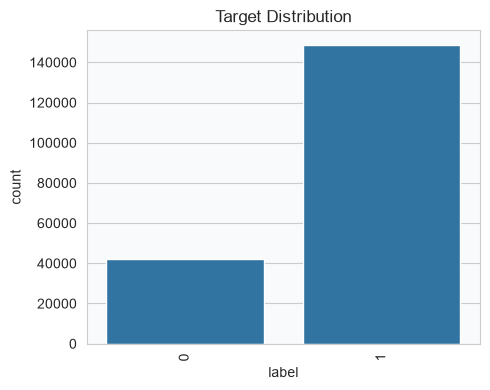

In [21]:
plot_class_distribution(df,BINARY_TARGET_COLUMN)

### Attack Target Analysis

In [22]:
get_target_distribution(df,ATTACK_TARGET_COLUMN)

type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64

In [23]:
get_target_rate(df,ATTACK_TARGET_COLUMN)

type
normal        22.071254
scanning      10.500121
ddos          10.496446
injection     10.481221
password      10.427145
dos            9.970915
backdoor       9.823388
xss            7.947016
ransomware     7.735964
mitm           0.546531
Name: proportion, dtype: float64

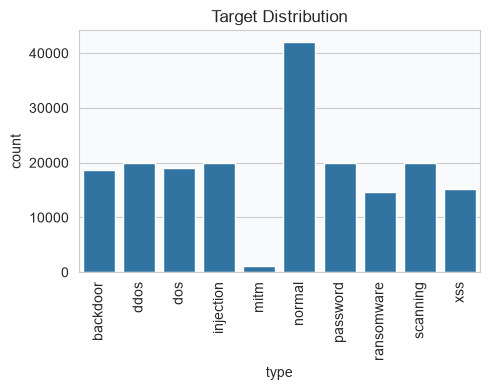

In [24]:
plot_class_distribution(df,ATTACK_TARGET_COLUMN)

* Is target distribution balanced?

The binary target is moderately imbalanced, with malicious traffic representing 76.3% of the dataset. Therefore, accuracy alone is not sufficient for model comparison.

## Numerical Analysis

In [25]:
numeric_columns = get_numeric_columns(df)
df.groupby("label")[numeric_columns].median().T

label,0,1
src_port,41185.000000,46670.000000
dst_port,53.000000,80.000000
duration,0.000965,0.000248
src_bytes,31.000000,0.000000
dst_bytes,0.000000,0.000000
missed_bytes,0.000000,0.000000
src_pkts,2.000000,1.000000
src_ip_bytes,186.000000,80.000000
dst_pkts,0.000000,1.000000
dst_ip_bytes,0.000000,40.000000


In [26]:
df.groupby("label")[numeric_columns].mean().T

label,0,1
src_port,33527.320599,41518.861339
dst_port,2415.476332,2057.035632
duration,4.745272,9.605103
src_bytes,2530.352807,366268.376275
dst_bytes,11617.497217,364677.187275
missed_bytes,10241.972122,46055.032735
src_pkts,31.381660,4.662665
src_ip_bytes,1416.593316,686.979230
dst_pkts,6.812631,3.522778
dst_ip_bytes,1597.620219,1799.912406


In [27]:
numeric_target_corr = (
    df[numeric_columns]
    .drop(columns=["label"], errors="ignore")
    .corrwith(df["label"])
    .sort_values(key=abs, ascending=False)
)
numeric_target_corr

dns_qtype                -0.283139
src_port                  0.176209
dns_qclass               -0.165270
src_pkts                 -0.114762
dns_rcode                -0.080716
http_status_code         -0.054420
dst_port                 -0.021323
http_request_body_len    -0.013998
src_ip_bytes             -0.012893
http_response_body_len   -0.009373
src_bytes                 0.008383
dst_bytes                 0.007717
dst_pkts                 -0.003920
duration                  0.003394
missed_bytes              0.002682
dst_ip_bytes              0.000419
dtype: float64

* Which features differ between normal and malicious traffic?
 
Normal and malicious traffic show different distributions in several
network-level features. The strongest numeric associations with the
binary target are observed for DNS-related variables, source/destination
ports and packet counts.

These relationships are exploratory associations.

### Visualize the difference in distribution

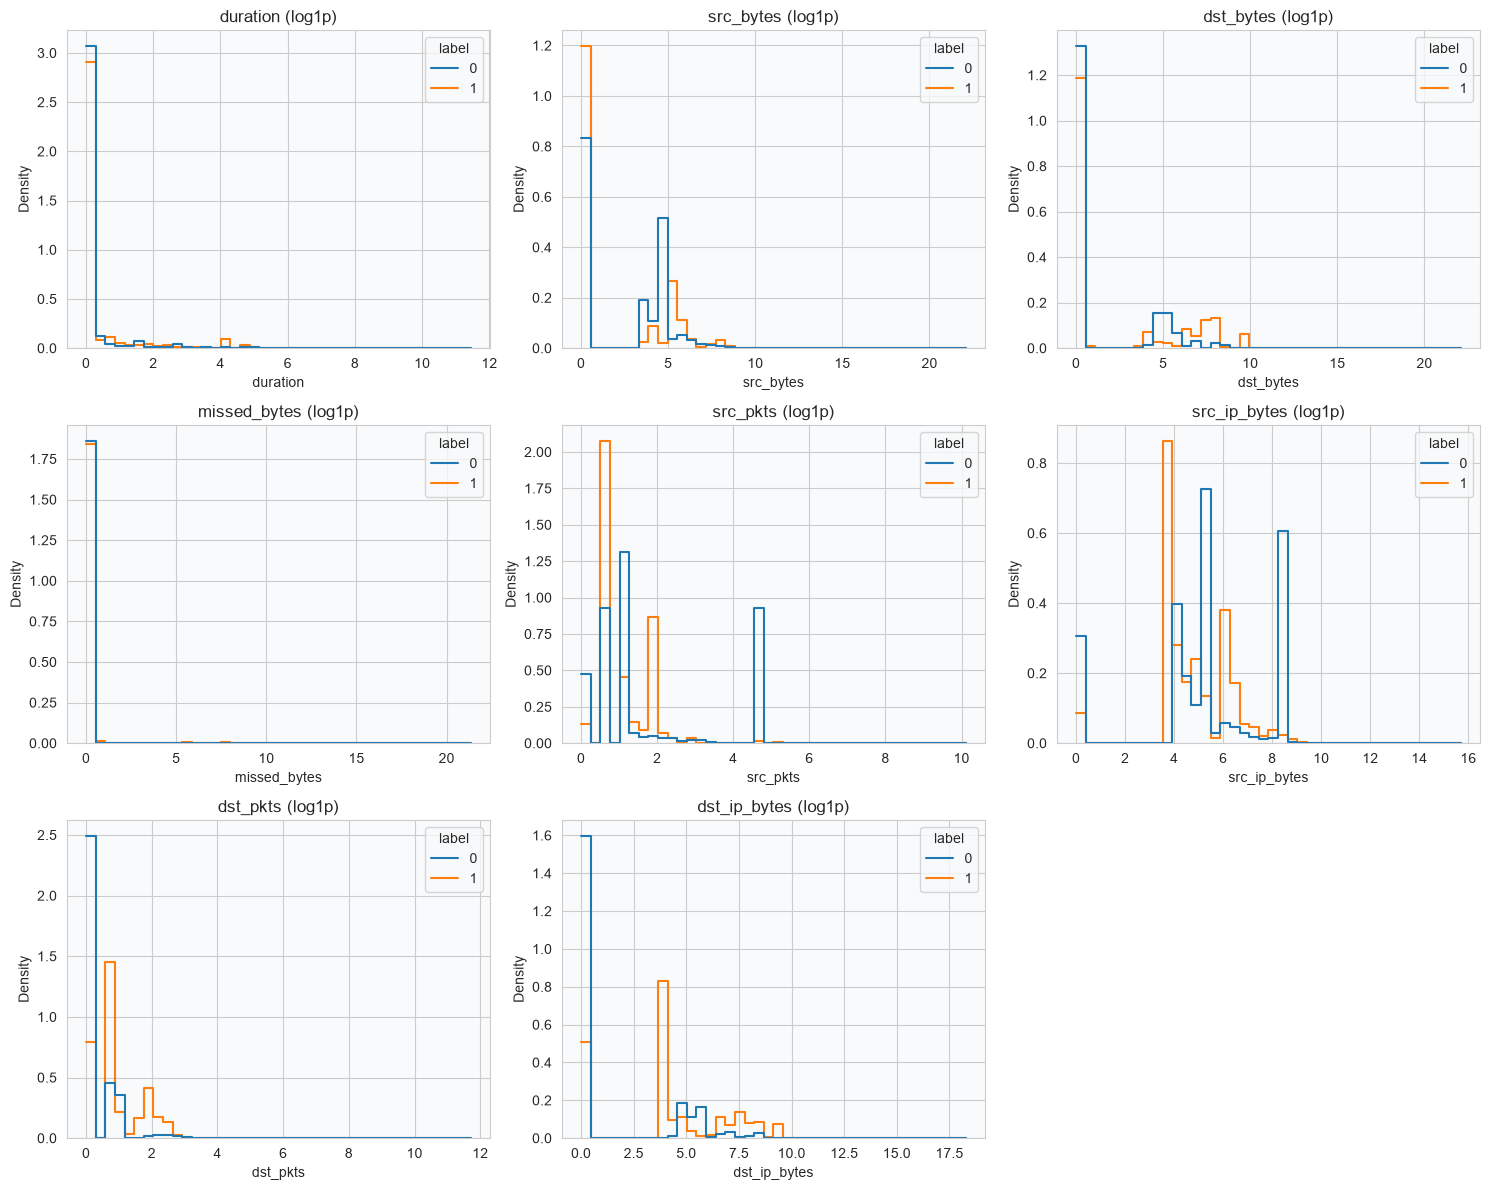

In [28]:
numeric_columns = get_numeric_columns(df.drop(columns=["label"]))
continuous_columns = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "missed_bytes",
    "src_pkts",
    "src_ip_bytes",
    "dst_pkts",
    "dst_ip_bytes"
]
# continuous_columns = [
#     col for col in get_numeric_columns(df)
#     if col != BINARY_TARGET_COLUMN
# ]
plot_numeric_distribution(df, continuous_columns, "label", log_scale=True)

#### Numeric Distribution Insights Table

| Feature & Type <br>(log1p) | Distribution Insights |
| :--- | :--- |
| **`duration`** | Normal traffic drops to zero instantly, while attack traffic stretches out with small peaks, showing longer connection times during malicious activity. |
| **`src_bytes`** & **`dst_bytes`** | Attackers send smaller payloads but receive almost zero bytes back. This heavily concentrated pattern at the bottom indicates scanning or reconnaissance. |
| **`missed_bytes`** | Both normal and attack traffic are completely frozen at zero, meaning there is no packet loss. This column does not provide any separating value. |
| **`src_pkts`** & **`dst_pkts`** | Attack traffic is tightly grouped at very low packet counts, showing a sharp spike. Attackers are firing minimal but specific packages to stay hidden. |
| **`src_ip_bytes`** & **`dst_ip_bytes`** | Normal and attack traffic show clearly separated peaks at the network layer. These distinct shapes will act as strong decision rules for the model. |

#### Conclusion:

* **Data Scaling:** Use `RobustScaler` instead of `StandardScaler` to handle the dense vertical outlier spikes that remain visible even after log transformation.
* **Model Selection:** Deploy tree-based algorithms like `Random Forest`, `XGBoost`, or `LightGBM`. The overlapping step-like data structure indicates non-linear distributions that linear models cannot split effectively.

### Outliers

While in standard data science these black dots are considered “noise” and are removed, in the field of cybersecurity these outliers may actually be the cyberattack itself.

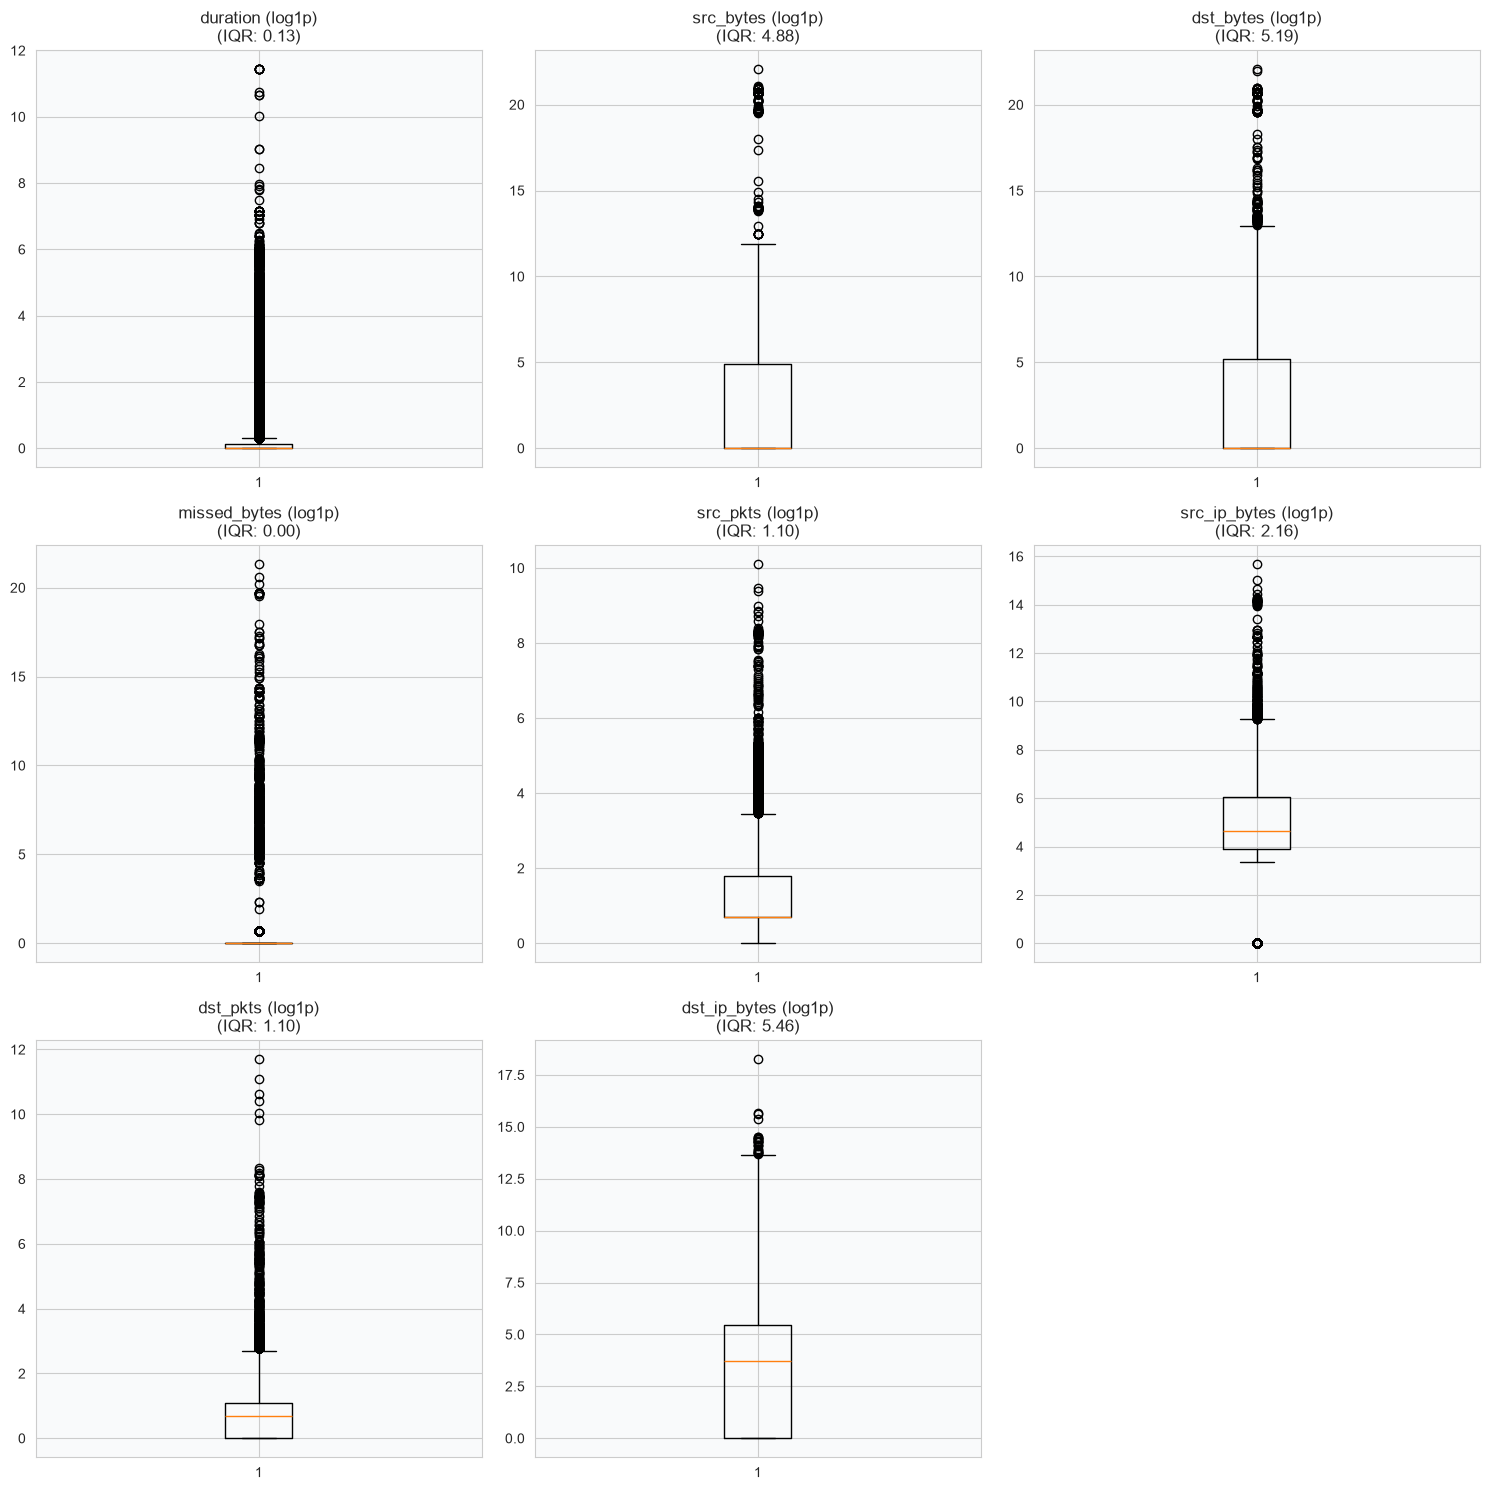

In [29]:
plot_outliers(df, continuous_columns, log_scale=True)

#### Outlier Insights Table

| Feature & IQR | Outlier Insights |
| :--- | :--- |
| **`duration`** (IQR: 0.13) | Attempts to establish a persistent presence on the network indicate unusual cyber activities, such as system scanning or data exfiltration. |
| **`src_bytes`** & **`dst_bytes`** (IQR: 4.88 / 5.19) | An exceptionally large data container was transferred within the dataset. This indicates the presence of serious cyberattacks—such as massive data exfiltration (data leakage or ransomware)—involving large exploit payloads or originating from IoT devices. |
| **`missed_bytes`** (IQR: 0.00) | The box itself has completely vanished vertically, and the IQR value is exactly 0.00. However, there are outliers shooting up to the level of 20. This indicates that 99% of the data is zero, yet massive packet losses occurred in a very small number of rows. |
| **`src_pkts`** & **`dst_pkts`** (IQR: 1.10 / 1.10) | The traces left by DDoS or brute-force (password-guessing) attacks—which deviate from standard packet-exchange routines and send thousands of packets per second—may be hidden within these black rings. |
| **`src_ip_bytes`** & **`dst_ip_bytes`** (IQR: 2.16 / 5.46) | The total traffic volume at the network layer exhibits a more balanced variance. |

#### Conclusion:

The heavy outliers in this dataset are not errors or noise; they are the actual fingerprints of cyberattacks (like DDoS, ransomware, and scanning). Traditional outlier removal methods (like Z-score or IQR clipping) must not be used, as deleting these points would delete the attacks themselves.
* **Feature Engineering Action:** To protect the machine learning model from being distorted by these massive spikes while still keeping the attack signals, a **RobustScaler** must be used during the preprocessing stage instead of standard scaling methods.



In [30]:
numeric_target_corr = (
    df[numeric_columns]
    .corrwith(df["label"])
    .sort_values(key=abs, ascending=False)
)
numeric_target_corr

dns_qtype                -0.283139
src_port                  0.176209
dns_qclass               -0.165270
src_pkts                 -0.114762
dns_rcode                -0.080716
http_status_code         -0.054420
dst_port                 -0.021323
http_request_body_len    -0.013998
src_ip_bytes             -0.012893
http_response_body_len   -0.009373
src_bytes                 0.008383
dst_bytes                 0.007717
dst_pkts                 -0.003920
duration                  0.003394
missed_bytes              0.002682
dst_ip_bytes              0.000419
dtype: float64

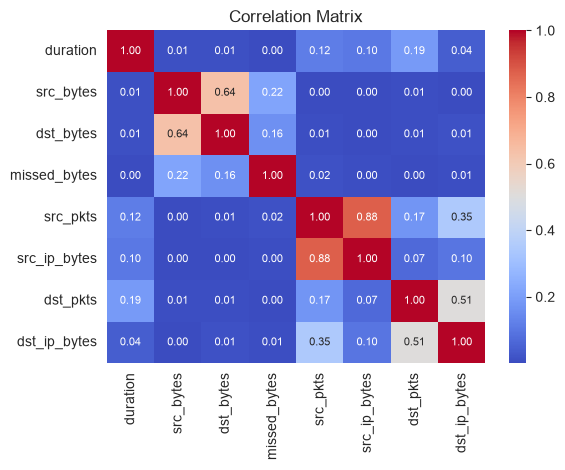

In [31]:
plot_correlation_heatmap(df, continuous_columns)

#### Conclusion:

The highest correlation in the dataset is between `src_pkts` and `src_ip_bytes` (0.88). While they are highly dependent, they do not reach the multicollinearity danger zone (>0.95), meaning we do not need to drop either of them immediately.

## Categorical Analysis

### Categorical Attack-Target Analysis

In [32]:
categorical_columns = get_categoric_columns(df)

for column in categorical_columns:
    print(f"\n--- {column} ---")
    
    ct = pd.crosstab(df[column], df["label"], normalize="index")
    
    sort_column = 1 if 1 in ct.columns else ct.columns[0]
    
    ct_sorted = ct.sort_values(by=sort_column, ascending=False).head(10)
    print(ct_sorted)


--- src_ip ---
label             0    1
src_ip                  
13.55.50.68     0.0  1.0
192.168.1.31    0.0  1.0
192.168.1.32    0.0  1.0
192.168.1.38    0.0  1.0
192.168.1.39    0.0  1.0
192.168.1.37    0.0  1.0
192.168.1.36    0.0  1.0
192.168.1.33    0.0  1.0
192.168.1.34    0.0  1.0
220.158.215.20  0.0  1.0

--- dst_ip ---
label             0    1
dst_ip                  
74.125.200.156  0.0  1.0
74.125.200.154  0.0  1.0
74.125.171.136  0.0  1.0
74.125.109.8    0.0  1.0
72.34.250.78    0.0  1.0
66.155.71.150   0.0  1.0
104.28.18.232   0.0  1.0
104.244.42.8    0.0  1.0
104.244.42.200  0.0  1.0
104.244.38.20   0.0  1.0

--- proto ---
label         0         1
proto                    
tcp    0.076646  0.923354
icmp   0.674033  0.325967
udp    0.748262  0.251738

--- service ---
label              0         1
service                       
dce_rpc     0.000000  1.000000
ftp         0.000000  1.000000
gssapi      0.000000  1.000000
smb         0.000000  1.000000
smb;gssapi  0.000000

### Network Endpoint Behavior

In [33]:
pd.crosstab(
    df["dst_port"],
    df["label"],
    normalize="index"
).sort_values(1, ascending=False).head(20)

# pd.crosstab(
#     df["src_port"],
#     df["label"],
#     normalize="index"
# ).sort_values(1, ascending=False).head(20)

label,0,1
dst_port,,
9,0.0,1.0
65389,0.0,1.0
10,0.0,1.0
11,0.0,1.0
12,0.0,1.0
4,0.0,1.0
6,0.0,1.0
65000,0.0,1.0
65129,0.0,1.0


### User-Agent Analysis
Which User-Agent values appear exclusively in malicious traffic?

In [34]:
pd.crosstab(
    df["http_user_agent"],
    df["label"]
).sort_values(1, ascending=False).head(10)

label,0,1
http_user_agent,,
Ruby,0,31
sqlmap/1.2#stable (http://sqlmap.org),0,2
hacking,0,2
Comos/0.9_(robot@xyleme.com),0,1
Mozilla/5.0 (Windows NT 6.3; rv:36.0) Gecko/20100101 Firefox/36.0,0,1
DataCha0s/2.0,0,1
Mozilla/4.08 [en] (WinNT; I ;Nav),0,1
DonutP; Windows98SE,0,1
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_0) AppleWebKit/537.36 (KHTML; like Gecko) Chrome/53.0.2785.143 Safari/537.36,0,1


### Attack Type and Protocol Analysis
Which network protocols are associated with different attack types?

In [35]:
pd.crosstab(
    df["type"],
    df["proto"],
    normalize="index"
).round(3)

proto,icmp,tcp,udp
type,,,
backdoor,0.000,0.999,0.001
ddos,0.000,0.736,0.264
dos,0.000,0.922,0.078
injection,0.000,0.963,0.037
mitm,0.055,0.399,0.547
normal,0.003,0.273,0.724
password,0.000,0.991,0.009
ransomware,0.000,0.998,0.002
scanning,0.000,0.971,0.029


### Categorical Feature Insights

Protocol and service distributions show significant differences between normal and malicious traffic.

While TCP traffic is strongly associated with malicious observations, the percentage of normal traffic is much higher in UDP.

In this dataset, certain service categories are observed only in malicious traffic. These patterns demonstrate that categorical network features can contain strong discriminative information and should not be overlooked simply because they are not numerical.

### Identifier Analysis

Although source and destination IP addresses were examined during EDA, ``src_ip`` and ``dst_ip`` were excluded from the model features because they may represent environment-specific identifiers
rather than generalizable traffic characteristics.

## Feature Engineering

### Binary

In [36]:
binary_df = create_features(
    df,
    leakage_columns=BINARY_LEAKAGE_COLUMNS
)
print(f"Original shape: {df.shape}")
print(f"Binary feature-engineered shape: {binary_df.shape}")

binary_df.head()

2026-08-13 23:42:38,246 - INFO - feature_engineering - Dropping leakage columns: ['type']
2026-08-13 23:42:38,249 - INFO - feature_engineering - Dropping identifier columns: ['src_ip', 'dst_ip', 'dns_query']
2026-08-13 23:42:38,320 - INFO - feature_engineering - Created 'has_ssl' from ['ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer']
2026-08-13 23:42:38,376 - INFO - feature_engineering - Created 'has_http' using non-empty HTTP text fields or non-zero HTTP numeric fields.
2026-08-13 23:42:38,485 - INFO - feature_engineering - Dropping zero-variance columns: ['weird_notice']
2026-08-13 23:42:38,506 - INFO - feature_engineering - Created ratio features: bytes_ratio, pkts_ratio
2026-08-13 23:42:38,514 - INFO - feature_engineering - Feature engineering completed. Final shape: (190474, 27)


Original shape: (190474, 44)
Binary feature-engineered shape: (190474, 27)


,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,weird_name,weird_addl,label,has_ssl,has_http,bytes_ratio,pkts_ratio
0,4444,49178,tcp,NaN,290.371539,101568,2592,OTH,0,108,108064,31,3832,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,39.170073,3.375
1,49180,8080,tcp,NaN,0.000102,0,0,REJ,0,1,52,1,40,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0.000000,0.500
2,49180,8080,tcp,NaN,0.000148,0,0,REJ,0,1,52,1,40,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0.000000,0.500
3,49180,8080,tcp,NaN,0.000113,0,0,REJ,0,1,48,1,40,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0.000000,0.500
4,49180,8080,tcp,NaN,0.000130,0,0,REJ,0,1,52,1,40,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0.000000,0.500


In [37]:
new_features = [
    column
    for column in binary_df.columns
    if column not in df.columns
]

new_features

['has_ssl', 'has_http', 'bytes_ratio', 'pkts_ratio']

In [38]:
binary_df["has_http"].value_counts(dropna=False)

has_http
0    190171
1       303
Name: count, dtype: int64

In [39]:
binary_df["has_ssl"].value_counts(dropna=False)

has_ssl
0    190073
1       401
Name: count, dtype: int64

In [40]:
binary_df = remove_exact_duplicates(binary_df)

2026-08-13 23:42:39,211 - INFO - preprocessing - Removed exact duplicates: 6972. Rows remaining: 183502.


### Attack classification

In [41]:
attack_df = df[
    df[BINARY_TARGET_COLUMN] == 1
].copy()

attack_df = create_features(
    attack_df,
    leakage_columns=ATTACK_LEAKAGE_COLUMNS
)

print(f"Attack-only shape: {attack_df.shape}")
print(f"Attack feature-engineered shape: {attack_df.shape}")

2026-08-13 23:42:39,351 - INFO - feature_engineering - Dropping leakage columns: ['label']
2026-08-13 23:42:39,355 - INFO - feature_engineering - Dropping identifier columns: ['src_ip', 'dst_ip', 'dns_query']
2026-08-13 23:42:39,420 - INFO - feature_engineering - Created 'has_ssl' from ['ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer']
2026-08-13 23:42:39,456 - INFO - feature_engineering - Created 'has_http' using non-empty HTTP text fields or non-zero HTTP numeric fields.
2026-08-13 23:42:39,555 - INFO - feature_engineering - Dropping zero-variance columns: ['weird_name', 'weird_addl', 'weird_notice']
2026-08-13 23:42:39,577 - INFO - feature_engineering - Created ratio features: bytes_ratio, pkts_ratio
2026-08-13 23:42:39,583 - INFO - feature_engineering - Feature engineering completed. Final shape: (148434, 25)


Attack-only shape: (148434, 25)
Attack feature-engineered shape: (148434, 25)


In [42]:
attack_df = remove_exact_duplicates(attack_df)

2026-08-13 23:42:39,950 - INFO - preprocessing - Removed exact duplicates: 6819. Rows remaining: 141615.


In [43]:
new_attack_features = [
    column
    for column in attack_df.columns
    if column not in df.columns
]

new_attack_features

['has_ssl', 'has_http', 'bytes_ratio', 'pkts_ratio']

In [44]:
attack_df["has_http"].value_counts(dropna=False)

has_http
0    141563
1        52
Name: count, dtype: int64

In [45]:
attack_df["has_ssl"].value_counts(dropna=False)

has_ssl
0    141613
1         2
Name: count, dtype: int64

* Which network-specific features can be derived from the existing variables?

Three candidate features were generated. `has_http` was removed because
it became zero-variance after transformation and therefore provided no
information to the model. The retained features were `has_ssl`,
`bytes_ratio` and `pkts_ratio`.

* Are there features that should be excluded because of leakage or lack of predictive value?

``type`` → Removed from the binary model.

``label`` → Removed from the attack model.

``src_ip``/``dst_ip`` → Removed as identifiers.

In [46]:
get_target_distribution(attack_df, "type")

type
ddos          19986
injection     19964
password      19847
backdoor      18710
scanning      18615
dos           14669
xss           14519
ransomware    14266
mitm           1039
Name: count, dtype: int64

## Feature Selection

Feature selection was performed using Random Forest feature importance on the training data. Features were selected after preprocessing to avoid data leakage.

## Train Validation Test Split

### Binary

In [47]:
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_data(binary_df, BINARY_TARGET_COLUMN)

### Attack

In [48]:
(
    X_attack_train,
    X_attack_val,
    X_attack_test,
    y_attack_train,
    y_attack_val,
    y_attack_test
) = split_data(
    attack_df,
    ATTACK_TARGET_COLUMN
)

In [49]:
(
    y_attack_train,
    y_attack_val,
    y_attack_test,
    attack_label_encoder
) = encode_target(
    y_attack_train,
    y_attack_val,
    y_attack_test
)

## Data Preprocessing

### Binary

In [50]:
binary_numeric_columns = get_numeric_columns(X_train)
binary_categorical_columns = get_categoric_columns(X_train)

binary_preprocessor = build_preprocessor(
    binary_numeric_columns,
    binary_categorical_columns
)

### Attack

In [51]:
attack_numeric_columns = get_numeric_columns(X_attack_train)
attack_categorical_columns = get_categoric_columns(X_attack_train)

attack_preprocessor = build_preprocessor(
    attack_numeric_columns,
    attack_categorical_columns
)

## Model Training

### Binary

In [52]:
binary_models = get_models()

binary_validation_results, binary_fitted_models = compare_models(
    binary_models,
    binary_preprocessor,
    X_train,
    y_train,
    X_val,
    y_val
)

binary_validation_results

2026-08-13 23:42:41,030 - INFO - modeling - Training logistic_regression...
c:\Users\beste\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
2026-08-13 23:45:55,102 - INFO - modeling - logistic_regression — F1: 0.6448
2026-08-13 23:45:55,103 - INFO - modeling - Training decision_tree...
2026-08-13 23:46:00,484 - INFO - modeling - decision_tree — F1: 0.9982
2026-08-13 23:46:00,485 - INFO - modeling - Training random_forest...
2026-08-13 23:46:08,345 - INFO - modeling - random_forest — F1: 0.9989
2026-08-13 23:46:08,347 - INFO - modeling - Training xgboost...
2026-08-13 23:46:13,052 - INFO - modeling - xgboost — F1: 0.9951


,accuracy,precision,recall,f1
random_forest,0.998883,0.998883,0.998883,0.998883
decision_tree,0.998174,0.998174,0.998174,0.998174
xgboost,0.995123,0.995120,0.995123,0.995114
logistic_regression,0.626495,0.670350,0.626495,0.644765


### Attack Classification

In [53]:
attack_models = get_models()

attack_validation_results, attack_fitted_models = compare_models(
    attack_models,
    attack_preprocessor,
    X_attack_train,
    y_attack_train,
    X_attack_val,
    y_attack_val
)

attack_validation_results

2026-08-13 23:46:13,070 - INFO - modeling - Training logistic_regression...
c:\Users\beste\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
2026-08-13 23:51:39,313 - INFO - modeling - logistic_regression — F1: 0.2197
2026-08-13 23:51:39,314 - INFO - modeling - Training decision_tree...
2026-08-13 23:51:43,050 - INFO - modeling - decision_tree — F1: 0.9811
2026-08-13 23:51:43,051 - INFO - modeling - Training random_forest...
2026-08-13 23:51:49,902 - INFO - modeling - random_forest — F1: 0.9854
2026-08-13 23:51:49,903 - INFO - modeling - Training xgboost...
2026-08-13 23:51:57,008 - INFO - modeling - xgboost — F1: 0.9749


,accuracy,precision,recall,f1
random_forest,0.985242,0.985891,0.985242,0.985446
decision_tree,0.981146,0.981128,0.981146,0.981135
xgboost,0.974755,0.975184,0.974755,0.974902
logistic_regression,0.265261,0.362628,0.265261,0.219712


## Validation Results

### Binary

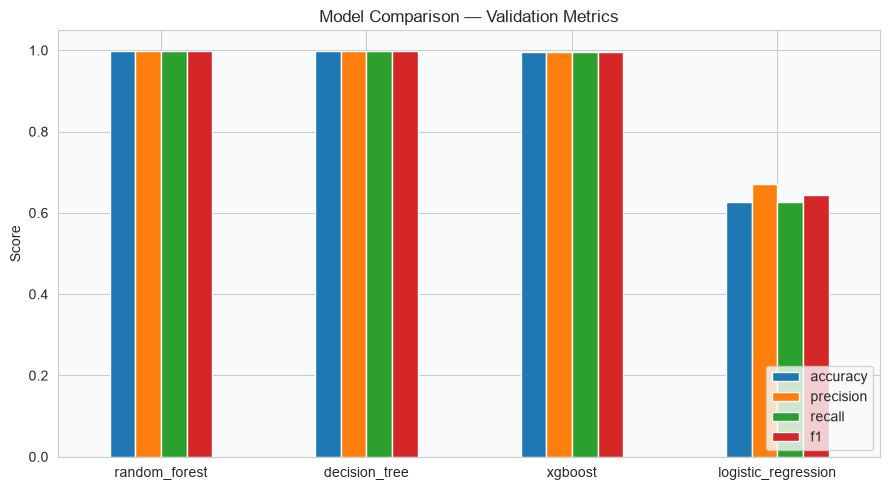

random_forest
accuracy     0.998883
precision    0.998883
recall       0.998883
f1           0.998883
Name: random_forest, dtype: float64


In [54]:
plot_model_comparison(binary_validation_results)

binary_best_model_name = binary_validation_results["f1"].idxmax()

binary_best_model = binary_fitted_models[
    binary_best_model_name
]

print(binary_best_model_name)
print(
    binary_validation_results.loc[
        binary_best_model_name
    ]
)

### Attack

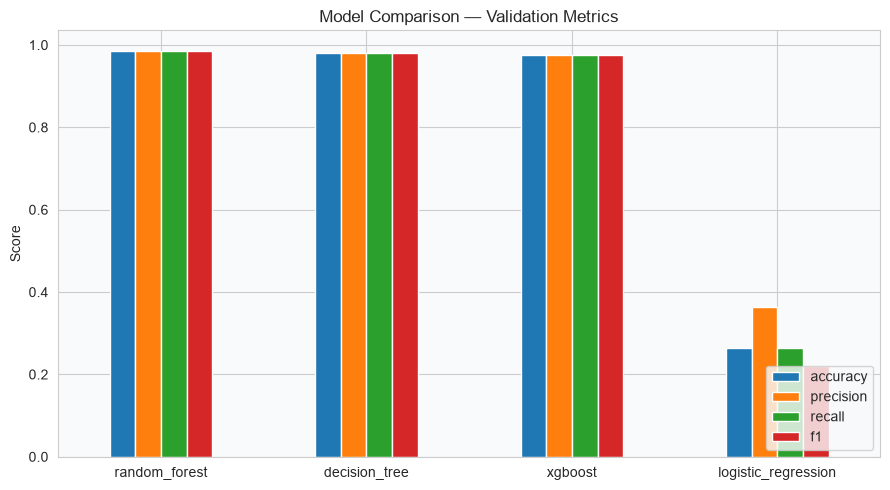

random_forest
accuracy     0.985242
precision    0.985891
recall       0.985242
f1           0.985446
Name: random_forest, dtype: float64


In [55]:
plot_model_comparison(attack_validation_results)

attack_best_model_name = attack_validation_results["f1"].idxmax()

attack_best_model = attack_fitted_models[
    attack_best_model_name
]

print(attack_best_model_name)
print(
    attack_validation_results.loc[
        attack_best_model_name
    ]
)

## Hyperparameter Tuning

### Binary

In [56]:
binary_param_grid = get_param_grid(
    binary_best_model_name
)

binary_tuned_model = tune_best_model(
    binary_best_model,
    binary_param_grid,
    X_train,
    y_train
)

2026-08-13 23:51:57,649 - INFO - modeling - Starting hyperparameter tuning...


Fitting 5 folds for each of 12 candidates, totalling 60 fits


2026-08-13 23:57:41,436 - INFO - modeling - Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
2026-08-13 23:57:41,438 - INFO - modeling - Best CV F1: 0.9987


### Attack

In [57]:
attack_param_grid = get_param_grid(
    attack_best_model_name
)

attack_tuned_model = tune_best_model(
    attack_best_model,
    attack_param_grid,
    X_attack_train,
    y_attack_train
)

2026-08-13 23:57:41,454 - INFO - modeling - Starting hyperparameter tuning...


Fitting 5 folds for each of 12 candidates, totalling 60 fits


2026-08-14 00:01:13,237 - INFO - modeling - Best params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
2026-08-14 00:01:13,238 - INFO - modeling - Best CV F1: 0.9847


## Final Evaluation

### Binary

In [58]:
binary_test_results = evaluate_on_test(
    binary_tuned_model,
    X_test,
    y_test
)

binary_test_results["metrics"]

2026-08-14 00:01:13,885 - INFO - evaluation - Test metrrics: {'accuracy': 0.998528650445492, 'precision': 0.9985282537458213, 'recall': 0.998528650445492, 'f1': 0.9985280311744119}


{'accuracy': 0.998528650445492,
 'precision': 0.9985282537458213,
 'recall': 0.998528650445492,
 'f1': 0.9985280311744119}

In [59]:
print(binary_test_results["report"])
print(binary_test_results["confusion_matrix"])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8380
           1       1.00      1.00      1.00     28321

    accuracy                           1.00     36701
   macro avg       1.00      1.00      1.00     36701
weighted avg       1.00      1.00      1.00     36701

[[ 8343    37]
 [   17 28304]]


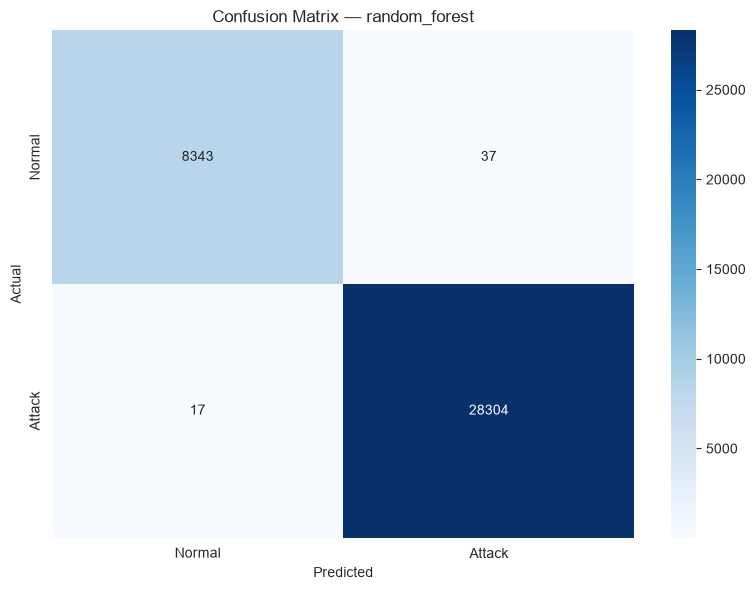

In [60]:
plot_confusion_matrix(
    y_test,
    binary_test_results["y_pred"],
    binary_best_model_name,
    labels=[0, 1],
    display_labels=["Normal", "Attack"],
)

Out of 36,701 total network packets, the model made only **54 mistakes** in total.

### Attack Classification

In [61]:
attack_test_results = evaluate_on_test(
    attack_tuned_model,
    X_attack_test,
    y_attack_test
)

attack_test_results["metrics"]

2026-08-14 00:01:14,797 - INFO - evaluation - Test metrrics: {'accuracy': 0.9856300533135615, 'precision': 0.9869312734194168, 'recall': 0.9856300533135615, 'f1': 0.9860297370464466}


{'accuracy': 0.9856300533135615,
 'precision': 0.9869312734194168,
 'recall': 0.9856300533135615,
 'f1': 0.9860297370464466}

In [62]:
print(attack_test_results["report"])
print(attack_test_results["confusion_matrix"])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3742
           1       0.99      0.98      0.99      3997
           2       0.99      0.98      0.98      2934
           3       0.98      0.97      0.98      3993
           4       0.64      0.96      0.77       208
           5       1.00      0.99      0.99      3969
           6       1.00      1.00      1.00      2853
           7       0.99      0.99      0.99      3723
           8       0.96      0.98      0.97      2904

    accuracy                           0.99     28323
   macro avg       0.95      0.98      0.96     28323
weighted avg       0.99      0.99      0.99     28323

[[3739    0    2    0    1    0    0    0    0]
 [   0 3926    0   31    2    1    2    0   35]
 [   0    1 2865    0   47    2    0   18    1]
 [   2   26    3 3874    8    0    0   12   68]
 [   1    1    3    3  199    1    0    0    0]
 [   0    0    1    1   33 3929    0    3    2]
 [   0 

Overall performance is high, but aggregate metrics hide weaker performance on the minority ``mitm`` class (support -> 199).

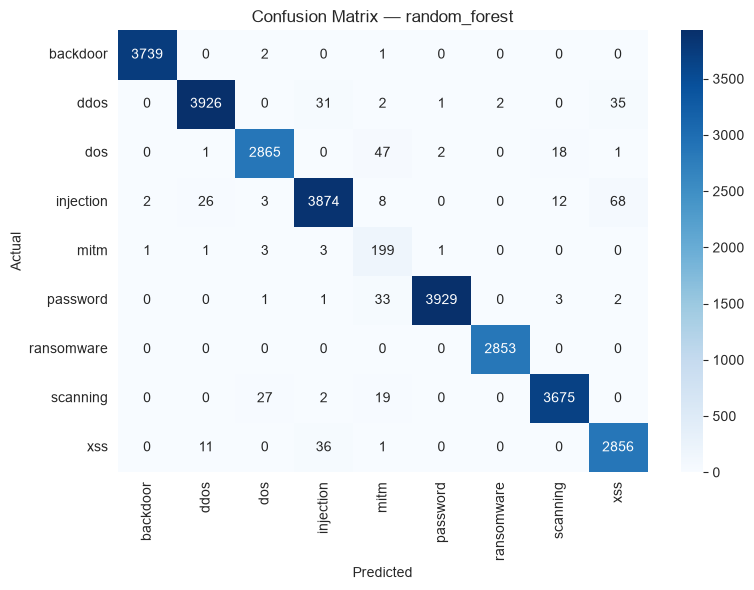

In [63]:
attack_labels = list(range(len(attack_label_encoder.classes_)))
attack_display_labels = list(attack_label_encoder.classes_)

plot_confusion_matrix(
    y_attack_test,
    attack_test_results["y_pred"],
    attack_best_model_name,
    labels=attack_labels,
    display_labels=attack_display_labels,
)

* The Random Forest model demonstrated exceptionally high success in distinguishing between different types of cyberattacks. The dark boxes along the diagonal represent the model's correct predictions, with performance for nearly every class being near-perfect. The model experienced only minor confusion between a few attack types that exhibit very similar characteristics.

* At the network layer, these attack types possess unique signatures regarding packet sizes, connection patterns (duration), and byte volumes (``src_bytes``/``dst_bytes``). The model was able to learn these footprints without simply memorizing them (i.e., without overfitting).

* Man-in-the-Middle (MitM) attacks typically involve covertly eavesdropping on network connections or intercepting traffic to steal credentials (such as passwords). Because the network packet performance and behavioral patterns associated with these attacks are so similar, the Random Forest model made slight errors in this area of ​​fine distinction.

With which classes was the MITM class confused?

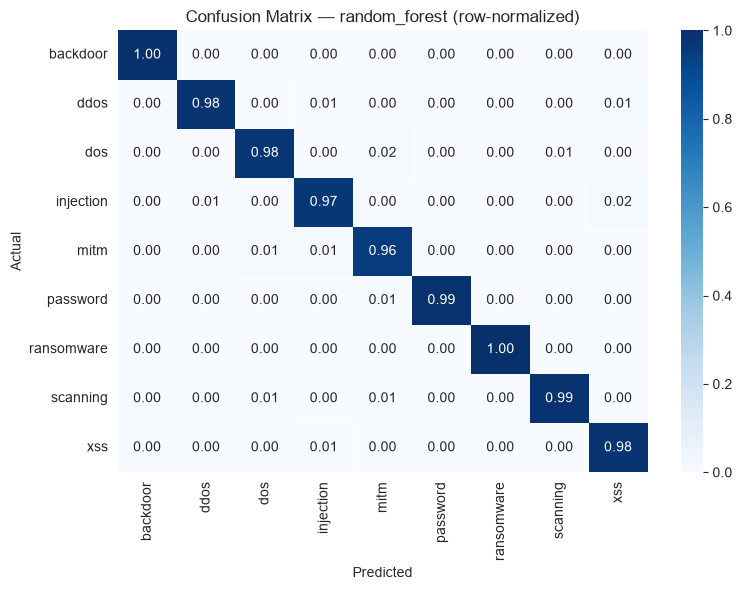

In [64]:
plot_confusion_matrix(
    y_attack_test,
    attack_test_results["y_pred"],
    f"{attack_best_model_name} (row-normalized)",
    labels=attack_labels,
    display_labels=attack_display_labels,
    normalize="true",
)

#### MitM Confusion Analysis

* **MitM vs. DoS (1% Overlap):** To redirect network traffic, MitM attacks often rely on continuous spoofing packets (like ARP or DNS spoofing). The model occasionally misinterprets this high-frequency routing activity as a Denial of Service (DoS) attempt.
* **MitM vs. Injection (1% Overlap):** During active session hijacking, attackers manipulate and inject custom payloads into data streams. The model catches this structural data change, causing a minor but logical overlap with Web Injection signatures.
* **Overall Strength:** With a `0.96` (96%) success rate, the model remains highly robust at isolating MitM behaviors from unrelated attack types.


### Evaluation Validity and Generalization Risk

Direct target leakage was prevented by excluding `type` from the binary model
and `label` from the attack-type model. Source and destination IP addresses
were also excluded because they can act as environment-specific identifiers.

However, the dataset contains duplicate observations, and the current split is
a stratified random split. Therefore, identical or highly similar records may
appear in both training and test data. The high test score should be interpreted
as performance on this dataset split, not as proof of performance on an unseen
production network.

### Final Test Interpretation

The test F1-score was measured at 0.998 for the binary model (Random Forest) and 0.985 for the attack-type model. An examination of the binary model's error distribution (see Error Analysis) reveals that errors are not distributed evenly across attack types: the `mitm` class exhibits the highest error rate (1.96%), a fact directly linked to it being the least represented class in the dataset (1,043/211,043; 0.49%). The same pattern recurs in the attack-type model, where the `mitm` class shows both the lowest precision (0.66) and the highest error rate (5.29%). This demonstrates that aggregate metrics (such as an F1-score of 0.986) can mask actual weaknesses regarding rare classes; in a SOC environment, this implies a high risk of overlooking rare yet critical attack types (like `mitm`).

## Explainability

### Binary

In [65]:
binary_feature_names = binary_tuned_model.named_steps[
    "preprocessor"
].get_feature_names_out()

binary_importance = get_feature_importance(
    binary_tuned_model,
    binary_feature_names
)

binary_importance.head(20)

categoric__proto_tcp         0.164012
numeric__pkts_ratio          0.146067
categoric__proto_udp         0.117827
numeric__src_pkts            0.068823
numeric__src_ip_bytes        0.061339
numeric__dst_port            0.056804
categoric__conn_state_S0     0.043775
numeric__dns_qclass          0.038812
numeric__dst_pkts            0.033189
numeric__src_port            0.031213
numeric__bytes_ratio         0.029561
numeric__duration            0.027216
numeric__dst_ip_bytes        0.026738
numeric__dns_qtype           0.024093
numeric__dst_bytes           0.019813
categoric__dns_rejected_F    0.018500
categoric__dns_rejected_T    0.017145
numeric__src_bytes           0.015106
categoric__conn_state_REJ    0.014347
categoric__conn_state_SHR    0.009277
dtype: float64

### Attack

In [66]:
attack_feature_names = attack_tuned_model.named_steps[
    "preprocessor"
].get_feature_names_out()

attack_importance = get_feature_importance(
    attack_tuned_model,
    attack_feature_names
)

attack_importance.head(20)

numeric__src_ip_bytes        0.165704
numeric__dst_port            0.117857
numeric__src_port            0.106576
numeric__duration            0.098217
numeric__src_bytes           0.080775
numeric__dst_ip_bytes        0.063511
numeric__src_pkts            0.042096
numeric__dst_bytes           0.041697
categoric__conn_state_REJ    0.039625
numeric__dst_pkts            0.028621
categoric__conn_state_OTH    0.028527
numeric__pkts_ratio          0.027411
numeric__bytes_ratio         0.026394
categoric__service_http      0.024513
categoric__conn_state_S0     0.022609
categoric__conn_state_SF     0.016109
categoric__conn_state_S1     0.015448
categoric__conn_state_SH     0.010154
categoric__dns_rejected_T    0.008609
categoric__proto_tcp         0.008481
dtype: float64

<Axes: title={'center': 'Top 20 Model Features'}>

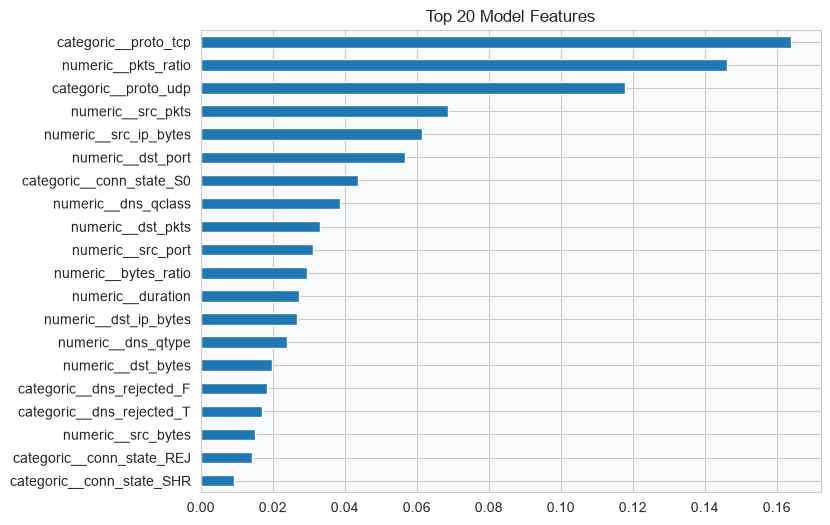

In [67]:
binary_importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Top 20 Model Features"
)

Just the top three features (`proto_tcp`, `pkts_ratio`, and `proto_udp`) control over **42.7%** of the model's final binary predictions. This proves that network layer protocols combined with traffic flow symmetry are highly effective indicators for intrusion detection.

<Axes: title={'center': 'Top 20 Model Features'}>

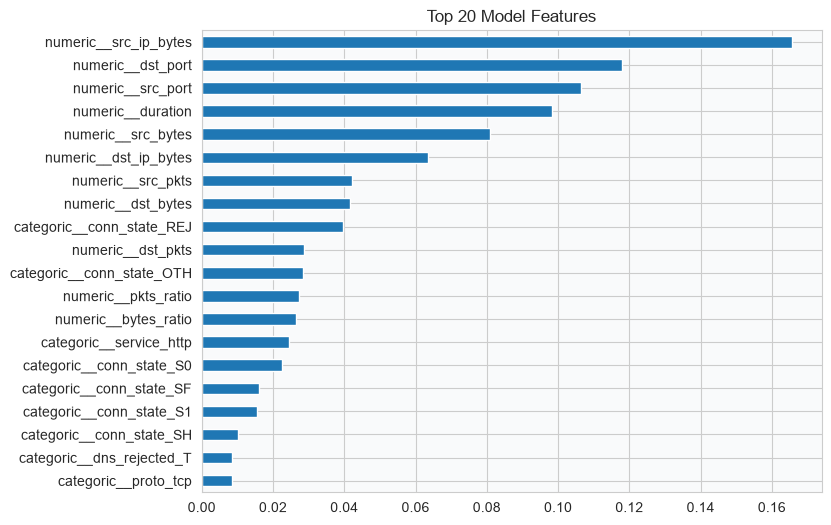

In [68]:
attack_importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Top 20 Model Features"
)

The machine learning model primarily relies on volumetric network layer features (`src_ip_bytes`), network endpoint behaviors (`dst_port`, `src_port`), and temporal signatures (`duration`) to detect network anomalies.

### Explainability — SHAP

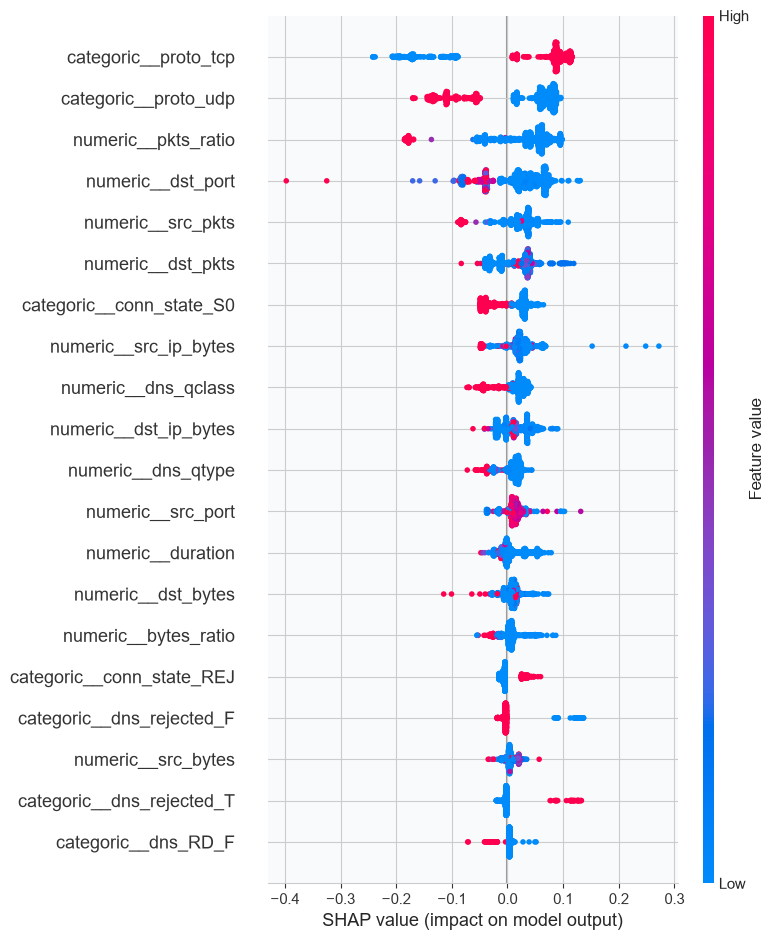

In [69]:
plot_shap_summary(binary_tuned_model, X_test, sample_size=1000, random_state=RANDOM_STATE)

#### Conclusion:

The model heavily relies on protocol types (`proto_tcp` and `proto_udp`) and packet flow statistics (`pkts_ratio`) to separate normal and malicious behaviors. TCP traffic is the single strongest indicator of cyberattacks in this specific ToN_IoT slice.
* **Model Validation Insight:** There is no evidence of data leakage here. The model is making its decisions based on legitimate network layer attributes (protocols, packet counts, and ports) rather than artificial target-clones like `type`. This proves the preprocessing and validation pipelines are working flawlessly.


## Error Analysis

### Binary

In [70]:
binary_error_analysis = analyze_errors(
    X_test,
    y_test,
    binary_test_results["y_pred"],
    group_col="proto"
)

binary_error_analysis.head(10)

2026-08-14 00:01:49,980 - INFO - evaluation - Error summary by 'proto':
       sample_count  error_count  error_rate
proto                                       
icmp             25            2    0.080000
udp            8144           27    0.003315
tcp           28532           25    0.000876


,sample_count,error_count,error_rate
proto,,,
icmp,25,2,0.080000
udp,8144,27,0.003315
tcp,28532,25,0.000876


#### Conclusion:

* **Key Takeaway:** The model is highly accurate, keeping error rates well below 1% for both TCP and UDP, which represent the vast majority of the network traffic.
* **Next Steps:** Although ICMP shows the highest error rate (8%), it only represents 2 actual mistakes due to a very small sample size (25 packets).

In [71]:
X_test_with_type = X_test.copy()

X_test_with_type["type"] = df.loc[
    X_test.index,
    ATTACK_TARGET_COLUMN
]

error_by_type = analyze_errors(
    X_test_with_type,
    y_test,
    binary_test_results["y_pred"],
    group_col="type"
)

error_by_type

2026-08-14 00:01:50,028 - INFO - evaluation - Error summary by 'type':
            sample_count  error_count  error_rate
type                                             
mitm                 204            4    0.019608
normal              8380           37    0.004415
ddos                3966            8    0.002017
dos                 2961            4    0.001351
scanning            3707            1    0.000270
injection           4036            0    0.000000
password            3938            0    0.000000
backdoor            3801            0    0.000000
xss                 2860            0    0.000000
ransomware          2848            0    0.000000


,sample_count,error_count,error_rate
type,,,
mitm,204,4,0.019608
normal,8380,37,0.004415
ddos,3966,8,0.002017
dos,2961,4,0.001351
scanning,3707,1,0.000270
injection,4036,0,0.000000
password,3938,0,0.000000
backdoor,3801,0,0.000000
xss,2860,0,0.000000


Model errors are not uniformly distributed across network protocols.
The attack-type classifier shows substantially higher error rates for
UDP traffic than TCP traffic. (UDP × attack type analysis)

### Attack

In [72]:
attack_error_analysis = analyze_errors(
    X_attack_test,
    y_attack_test,
    attack_test_results["y_pred"],
    group_col="proto"
)

attack_error_analysis.head(10)

2026-08-14 00:01:50,057 - INFO - evaluation - Error summary by 'proto':
       sample_count  error_count  error_rate
proto                                       
udp            2153          277    0.128658
tcp           26161          130    0.004969
icmp              9            0    0.000000


,sample_count,error_count,error_rate
proto,,,
udp,2153,277,0.128658
tcp,26161,130,0.004969
icmp,9,0,0.000000


The model displays near-perfect precision over TCP, achieving an incredibly low error rate of 0.49% across more than 26,000 packets. ICMP attacks were also classified with 100% accuracy, though the sample size was very small (9 packets).

In [73]:
X_attack_test_with_type = X_attack_test.copy()
X_attack_test_with_type["type"] = attack_label_encoder.inverse_transform(y_attack_test)

attack_error_by_type = analyze_errors(
    X_attack_test_with_type,
    y_attack_test,
    attack_test_results["y_pred"],
    group_col="type"
)
attack_error_by_type

2026-08-14 00:01:50,089 - INFO - evaluation - Error summary by 'type':
            sample_count  error_count  error_rate
type                                             
mitm                 208            9    0.043269
injection           3993          119    0.029802
dos                 2934           69    0.023517
ddos                3997           71    0.017763
xss                 2904           48    0.016529
scanning            3723           48    0.012893
password            3969           40    0.010078
backdoor            3742            3    0.000802
ransomware          2853            0    0.000000


,sample_count,error_count,error_rate
type,,,
mitm,208,9,0.043269
injection,3993,119,0.029802
dos,2934,69,0.023517
ddos,3997,71,0.017763
xss,2904,48,0.016529
scanning,3723,48,0.012893
password,3969,40,0.010078
backdoor,3742,3,0.000802
ransomware,2853,0,0.000000


Model errors are not distributed evenly across network protocols.

In terms of binary attack detection, the error rate observed in ICMP traffic is the highest.

In terms of attack type classification, the error rate in UDP traffic is significantly higher than that in TCP traffic.

These results highlight protocol-specific subsets that require more detailed analysis, rather than evaluating the overall test score as an indicator representing each traffic segment.

## Conclusion

This project established a two-stage attack detection system using TON_IoT network traffic data: first, a normal/attack distinction (binary classification), followed by attack-type classification (multiclass). Random Forest demonstrated the best performance in both stages (binary F1: 0.998, attack-type F1: 0.986); it was observed that tree-based models captured patterns in categorical protocol variables (`conn_state`, `proto`) far more effectively than Logistic Regression.

**Limitations**:
- The `mitm` class is significantly underrepresented (0.49%) and exhibits the highest error rate in both models; in a real-world deployment, strategies such as collecting additional data or applying class weighting for this class might be required.
- Duplicate records in the dataset (nearly 13%) were removed prior to splitting to avoid the risk of train/test leakage; however, this does not guarantee generalization performance in a real production environment.
- Environment-specific identifiers such as `dns_query` (see Explainability) pose a risk of the model memorizing specific laboratory signals; such features require a thorough review before real-world deployment.
- The model was trained on data collected from a simulated IoT environment; its ability to generalize to a different network topology has not been verified.